In [3]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
from rasterio.features import shapes
import rasterio
from shapely.geometry import shape
import contextily as cx

In [4]:
basins_eu_me = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
rivers_eu = gpd.read_file("../data/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu.shp")
countries = gpd.read_file("../data/world-administrative-boundaries/world-administrative-boundaries.shp")
mines = gpd.read_file("../data/mine_polygons/74548_projected polygons.shp")
flo_IPB = xr.open_dataset("../data/flo_IPB_last_date.nc")


In [5]:
mask_strahler_five = rivers_eu["ORD_STRA"] >= 5
rivers_eu_five = rivers_eu[mask_strahler_five]

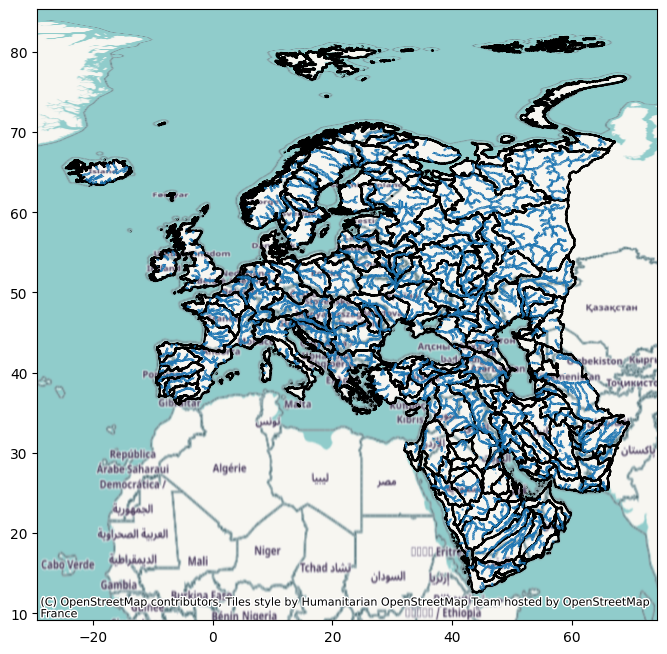

In [6]:
ax = basins_eu_me.boundary.plot(edgecolor = "k", figsize= (8, 8))
rivers_eu_five.plot(ax = ax)
cx.add_basemap(ax, crs=rivers_eu_five.crs);

In [7]:
IPB = basins_eu_me.iloc[45:53]
spain_mask  = countries["English_Nam"] == "Spain" 
portugal_mask = countries["English_Nam"] == "Portugal"
mask_iberia = spain_mask | portugal_mask
iberia = countries[mask_iberia]

In [8]:
rivers_in_IPB = gpd.sjoin(rivers_eu, IPB, predicate='intersects', how='inner')

In [9]:
print(flo_IPB["qav"].values.max())
print(flo_IPB["qav"].values.min())

nan
nan


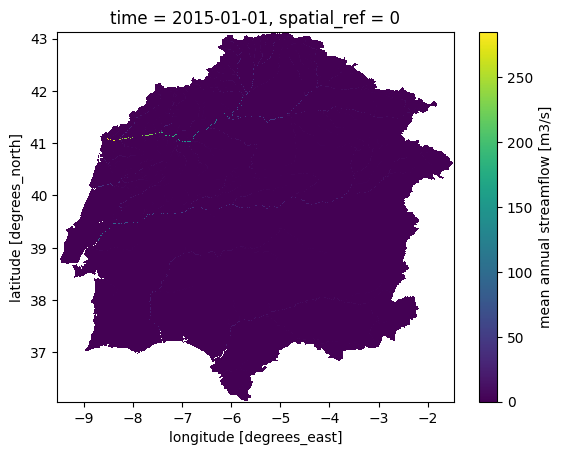

In [10]:
flo_IPB["qav"].plot()

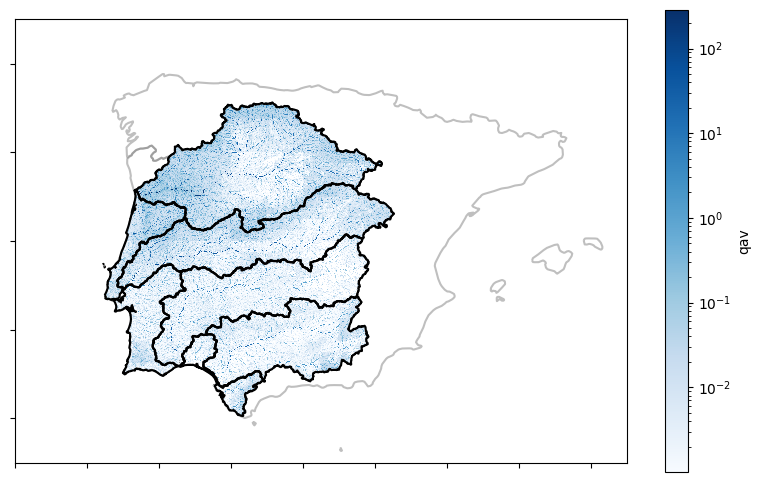

In [11]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize = (8, 8))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k.png", dpi = 200)
plt.show()
plt.close()

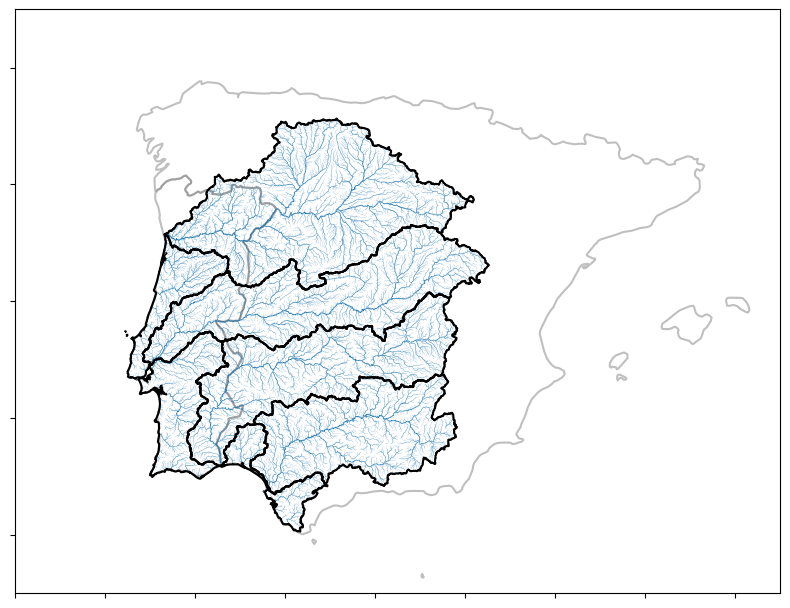

In [12]:
fig, ax = plt.subplots(figsize = (8, 8))
sizes = rivers_in_IPB["ORD_STRA"].fillna(1).astype(float) * 0.1
IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)
rivers_in_IPB.plot(ax = ax,linewidth=sizes)
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_hydrorivers.png", dpi = 200)
plt.show()
plt.close()

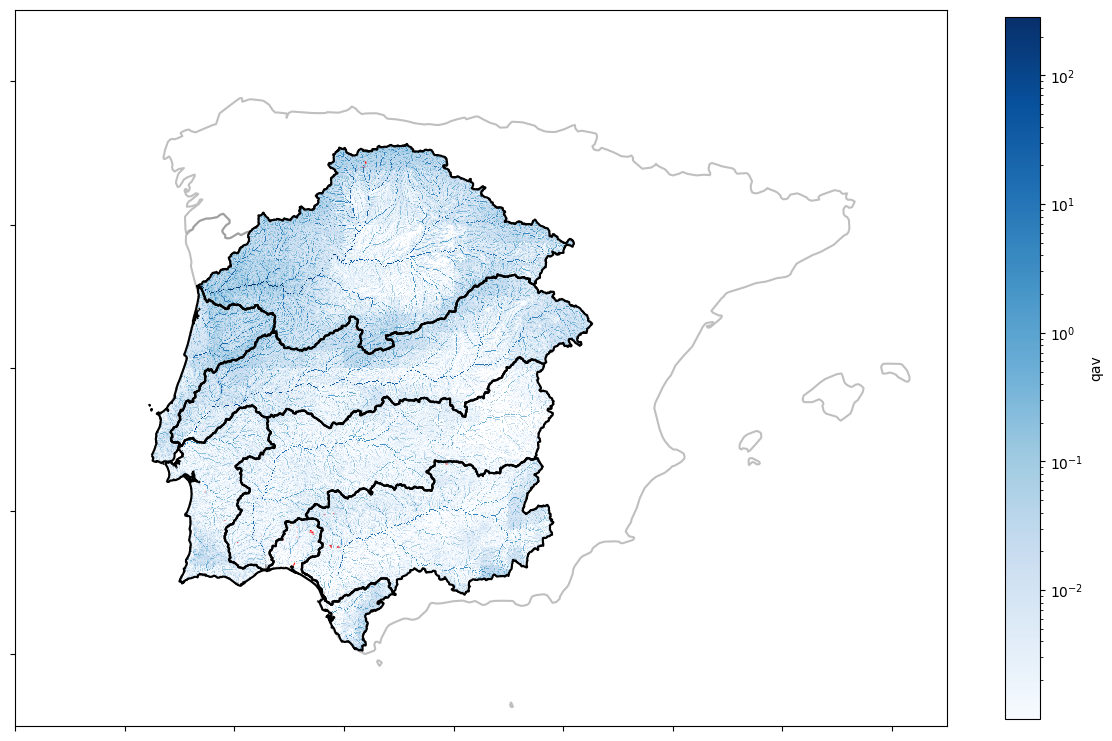

In [13]:
mines.to_crs(4326, inplace = True)
IPB_mines = gpd.sjoin(mines, IPB, predicate='intersects', how='inner')

fig, ax = plt.subplots(figsize = (12, 12))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})
IPB_mines.plot(ax = ax, color = "red")
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k_mines.png", dpi = 200)
plt.show()
plt.close()


In [14]:
mines_raster = xr.open_dataset("../data/mines_raster_IPB.tif")
mines_raster

<xarray.Dataset> Size: 3MB
Dimensions:      (band: 1, x: 970, y: 848)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 8kB -9.546 -9.538 -9.529 ... -1.487 -1.479 -1.471
  * y            (y) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.11 43.12
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 3MB ...

In [15]:
mindat_po_df = pd.read_csv("../data/mindat_data/Portugal_pyrite.csv")
mindat_sp_df = pd.read_csv("../data/mindat_Data/Spain_pyrite.csv")
mindat_IPB_df = pd.concat([mindat_sp_df, mindat_po_df])
mindat_mineral_locations_IPB = gpd.points_from_xy(mindat_IPB_df["longitude"], mindat_IPB_df["latitude"], crs = "EPSG:4326")

In [16]:
mindat_mineral_locations_IPB = gpd.GeoDataFrame(mindat_mineral_locations_IPB)

In [17]:
IPB_mines.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

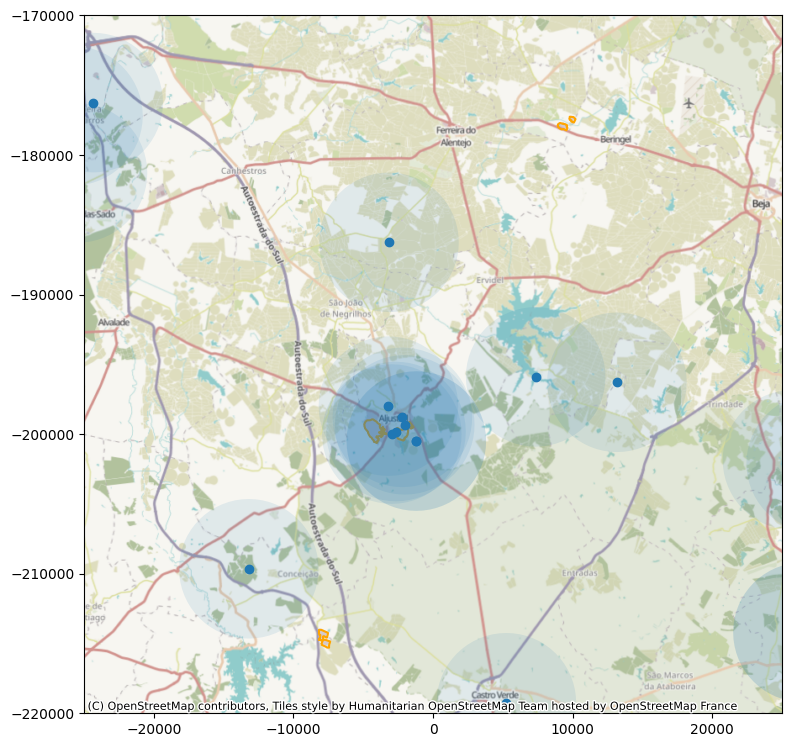

In [18]:
#37,8452°  -8,2005° : 37,9088°  -8,1342°
#https://www.mindat.org/a/aljustrel_mines
#https://www.mindat.org/loc-46429.ml
#https://www.mindat.org/loc-435303.html
#https://www.mindat.org/loc-204950.html

# setting crs to a EPSG:3763
IPB_mines = IPB_mines.to_crs(epsg = 3763)
mindat_mineral_locations_IPB = mindat_mineral_locations_IPB.set_geometry(col = 0).to_crs(epsg = 3763)
fig, ax = plt.subplots(figsize = (8, 8))

IPB_mines.boundary.plot(ax = ax, color = "orange", zorder= 1)
ax.set_xlim(-25000,  25000)
ax.set_ylim(-220000, -170000)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
# ax.set_xticklabels("")
# ax.set_yticklabels("")
plt.tight_layout()
cx.add_basemap(ax = ax, crs = IPB_mines.crs)
mindat_mineral_locations_IPB.plot(ax = ax);
mindat_mineral_locations_IPB.buffer(5000).plot(ax = ax, alpha=0.1);
IPB_mines = IPB_mines.to_crs(epsg = 4326)
mindat_mineral_locations_IPB = mindat_mineral_locations_IPB.to_crs(epsg = 4326)

In [19]:


raster = rxr.open_rasterio("../data/mines_raster_IPB.tif")

# the raster is in degrees, want to work in meters for accurate buffering
# reproject raster to a projected CRS (EPSG:3763 for Portugal)
raster_proj = raster.rio.reproject("EPSG:3763")

points = mindat_mineral_locations_IPB.set_geometry(col=0)
points = points.to_crs("EPSG:3763")

buffered = points.buffer(5000)



# clip raster using projected coordinates
filtered = raster_proj.rio.clip(buffered.geometry, buffered.crs, drop=True)
print(f"og shape = {raster.shape}, Filtered shape: {filtered.shape}")
print(f"Cells kept: {filtered.count().values} of og: {raster.count().values}")


og shape = (1, 848, 970), Filtered shape: (1, 987, 881)
Cells kept: 869547 of og: 822560


In [20]:
filtered

<xarray.DataArray (band: 1, y: 987, x: 881)> Size: 3MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(1, 987, 881), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 8kB 4.051e+05 4.043e+05 ... -3.961e+05 -3.969e+05
  * x            (x) float64 7kB -1.175e+05 -1.167e+05 ... 5.975e+05 5.983e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0.0

In [52]:
raster = rxr.open_rasterio("../data/mines_raster_IPB.tif")

In [53]:

points = mindat_mineral_locations_IPB.set_geometry(col=0)
points_wgs84 = points.to_crs(raster.rio.crs)

In [54]:


# Create buffer in degrees (approximate 5km at Portugal latitude)
# 5km ≈ 0.045 degrees longitude, 0.045 degrees latitude at ~39°N
buffer_deg = 0.045
buffered_wgs84 = points_wgs84.buffer(buffer_deg)

# clip
filtered_wgs84 = raster.rio.clip(buffered_wgs84.geometry, buffered_wgs84.crs, drop=True)

print(f"Original: {raster.shape}")
print(f"Filtered (WGS84): {filtered_wgs84.shape}")


C:\Users\luuc_\AppData\Local\Temp\ipykernel_6672\1671576093.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered_wgs84 = points_wgs84.buffer(buffer_deg)


Original: (1, 848, 970)
Filtered (WGS84): (1, 848, 962)


In [55]:
filtered_wgs84.to_netcdf("../data/filtered_mines_ipb.nc")

In [56]:
filtered_wgs84

<xarray.DataArray (band: 1, y: 848, x: 962)> Size: 3MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(1, 848, 962), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.11 43.12
  * x            (x) float64 8kB -9.479 -9.471 -9.463 ... -1.487 -1.479 -1.471
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0.0

In [26]:
hydir_eu = rxr.open_rasterio("../data/hyd_eu_dir_30s.tif")

In [32]:
your_dataarray = hydir_eu

In [33]:
import numpy as np
# Check the DataArray structure
print(your_dataarray)
print("\nShape:", your_dataarray.shape)
print("\nUnique values in the array:")
unique_vals = np.unique(your_dataarray.values)
print(unique_vals)

# Check basic statistics
print("\nValue counts:")
vals, counts = np.unique(your_dataarray.values, return_counts=True)
for v, c in zip(vals, counts):
    print(f"Value {v}: {c} pixels ({c/your_dataarray.size*100:.2f}%)")

# Check for special values
print(f"\nNumber of NoData pixels (255): {(your_dataarray.values == 255).sum()}")
print(f"Number of inland sinks (247): {(your_dataarray.values == 247).sum()}")

<xarray.DataArray (band: 1, y: 8640, x: 11400)> Size: 98MB
[98496000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 69kB 84.0 83.99 83.98 83.97 ... 12.02 12.01 12.0
  * x            (x) float64 91kB -25.0 -24.99 -24.98 ... 69.98 69.99 70.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    RepresentationType:  THEMATIC
    _FillValue:          255
    scale_factor:        1.0
    add_offset:          0.0
    long_name:           Band_1

Shape: (1, 8640, 11400)

Unique values in the array:
[  0   1   2   4   8  16  32  64 128 255]

Value counts:
Value 0: 371425 pixels (0.38%)
Value 1: 4384549 pixels (4.45%)
Value 2: 2516617 pixels (2.56%)
Value 4: 6103389 pixels (6.20%)
Value 8: 2577081 pixels (2.62%)
Value 16: 4743901 pixels (4.82%)
Value 32: 2471281 pixels (2.51%)
Value 64: 6132394 pixels (6.23%)
Value 128: 2685314 pixels (2.73%)
Value 255: 66510049 pixels (67.53%)

Number of NoData pixels (255): 66510049
Nu

Subset values (100x100):
[[[255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  ...
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]]]

Flow direction at (-10.0, 50.0): [255]


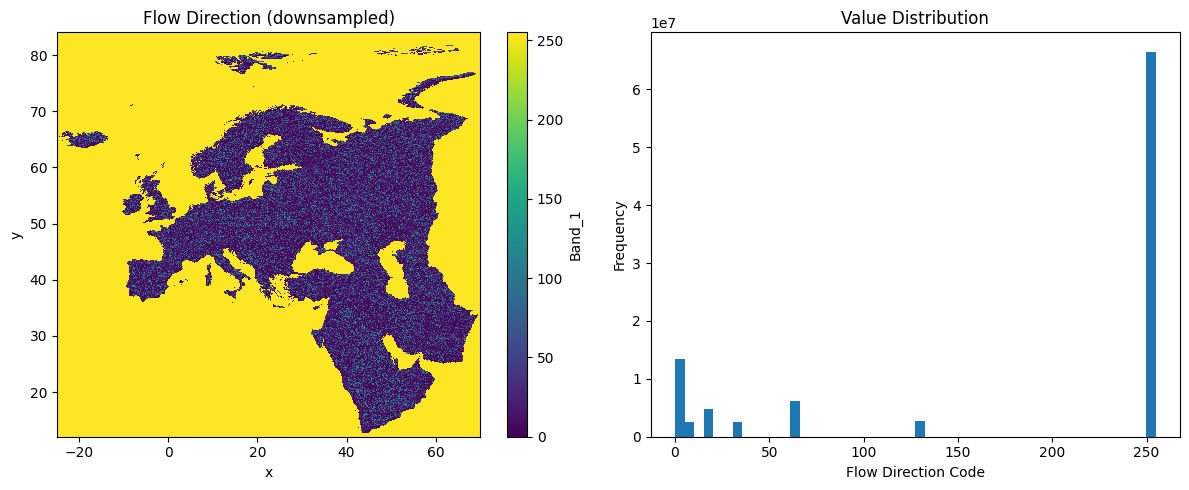

In [34]:
import matplotlib.pyplot as plt

# Method 1: Extract a small geographic region
# Let's take a 100x100 pixel window somewhere in the middle
subset = your_dataarray.isel(x=slice(5000, 5100), y=slice(5000, 5100))
print("Subset values (100x100):")
print(subset.values)

# Method 2: Look at specific coordinates
# Check flow direction at a specific lat/lon
lon, lat = -10.0, 50.0  # Example coordinates
# Find nearest pixel
direction_at_point = your_dataarray.sel(x=lon, y=lat, method="nearest")
print(f"\nFlow direction at ({lon}, {lat}): {direction_at_point.values}")

# Method 3: Create a quick visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the full array (downsampled for speed)
your_dataarray[::10, ::10].plot(ax=axes[0], cmap='viridis')
axes[0].set_title('Flow Direction (downsampled)')

# Plot histogram of values
axes[1].hist(your_dataarray.values.flatten(), bins=50)
axes[1].set_title('Value Distribution')
axes[1].set_xlabel('Flow Direction Code')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
def hydrosheds_to_outflow_ids(flow_dir_da):
    """
    Convert HydroSHEDS flow direction to outflow IDs.
    Returns a DataArray with same dimensions where each cell contains
    the ID of the cell it flows to, or 0 if no outflow.
    """
    # Handle the band dimension - extract the 2D array
    if len(flow_dir_da.shape) == 3:
        # Has band dimension: shape is (1, 8640, 11400)
        flow_dir_2d = flow_dir_da.values[0, :, :]  # Now shape: (8640, 11400)
        y_coords = flow_dir_da.y.values
        x_coords = flow_dir_da.x.values
    else:
        # Already 2D
        flow_dir_2d = flow_dir_da.values
        y_coords = flow_dir_da.y.values
        x_coords = flow_dir_da.x.values

    nrows, ncols = flow_dir_2d.shape

    cell_ids = np.arange(nrows * ncols).reshape((nrows, ncols))
    
    # Initialize outflow ID array with -1 (no outflow)
    outflow_ids = np.full((nrows, ncols), -1, dtype=np.int64)
    
    # HydroSHEDS encoding mapping to row/col offsets
    # Based on documentation: 1=E, 2=SE, 4=S, 8=SW, 16=W, 32=NW, 64=N, 128=NE
    encoding_to_offset = {
        1: (0, 1),    # E
        2: (1, 1),    # SE
        4: (1, 0),    # S
        8: (1, -1),   # SW
        16: (0, -1),   # W
        32: (-1, -1),  # NW
        64: (-1, 0),   # N
        128: (-1, 1),   # NE
        # Special codes
        0: (0, 0),    # Inland depression, flows to itself
        #255: (0, 0),  # NoData - will remain -1
    }
    
    # Process each valid flow direction
    for code, (dy, dx) in encoding_to_offset.items():
        if code == 255:  # Skip NoData
            continue
            
        # Find all cells with this flow direction
        mask = flow_dir_2d == code
        
        if mask.any():
            # Get indices of these cells
            rows, cols = np.where(mask)
            
            # Calculate target coordinates
            target_rows = rows + dy
            target_cols = cols + dx
            
            # Check bounds
            valid = (target_rows >= 0) & (target_rows < nrows) & \
                    (target_cols >= 0) & (target_cols < ncols)
            
            # Assign outflow IDs for valid targets
            valid_rows = rows[valid]
            valid_cols = cols[valid]
            valid_target_rows = target_rows[valid]
            valid_target_cols = target_cols[valid]
            
            outflow_ids[valid_rows, valid_cols] = cell_ids[valid_target_rows, valid_target_cols]
    
    # Create xarray DataArray with same coordinates
    outflow_da = xr.DataArray(
        outflow_ids,
        dims=["y", "x"],
        coords={"y": y_coords, "x": x_coords},
        attrs={'description': 'Outflow cell IDs', 'nodata': -1}
    )
    
    return outflow_da

# Apply to your data
outflow_ids = hydrosheds_to_outflow_ids(your_dataarray)

# Now you have both flow directions and outflow IDs
print("Sample mapping:")
for i in range(1000, 1005):
    for j in range(1000, 1005):
        dir_val = your_dataarray.values[0, i, j]
        outflow_val = outflow_ids.values[i, j]
        if outflow_val != -1:  # Skip NoData
            print(f"Cell ({i},{j}): Direction={dir_val}, Outflow_ID={outflow_val}")

Sample mapping:


In [51]:
outflow_ids.to_netcdf("../data/hyd_eu_outflow_ids.nc")

In [57]:
def create_geographic_outflow_ids(flow_dir_da):
    """
    Create outflow IDs using geographic coordinates as strings.
    Format: "lat,lon" (e.g., "50.125,-10.375")
    """
    # Extract data
    if len(flow_dir_da.shape) == 3:
        flow_data = flow_dir_da.values[0, :, :]
    else:
        flow_data = flow_dir_da.values
    
    nrows, ncols = flow_data.shape
    y_coords = flow_dir_da.y.values  # Latitude
    x_coords = flow_dir_da.x.values  # Longitude
    
    # Create array for geographic IDs (as strings)
    # Using object dtype for strings
    outflow_geo_ids = np.full((nrows, ncols), "", dtype=object)
    
    # ESRI encoding
    encoding_to_offset = {
        1: (0, 1), 2: (1, 1), 4: (1, 0), 8: (1, -1),
        16: (0, -1), 32: (-1, -1), 64: (-1, 0), 128: (-1, 1),
        0: (0, 0), 247: (0, 0)
    }
    
    # Process
    for code, (dy, dx) in encoding_to_offset.items():
        if code == 255:
            continue
            
        mask = flow_data == code
        if not mask.any():
            continue
            
        rows, cols = np.where(mask)
        target_rows = rows + dy
        target_cols = cols + dx
        
        # Check bounds
        valid = (target_rows >= 0) & (target_rows < nrows) & \
                (target_cols >= 0) & (target_cols < ncols)
        
        valid_idx = np.where(valid)[0]
        
        if len(valid_idx) > 0:
            valid_rows = rows[valid_idx]
            valid_cols = cols[valid_idx]
            valid_target_rows = target_rows[valid_idx]
            valid_target_cols = target_cols[valid_idx]
            
            # Create geographic ID strings
            for r, c, tr, tc in zip(valid_rows, valid_cols, valid_target_rows, valid_target_cols):
                lat = y_coords[tr]
                lon = x_coords[tc]
                outflow_geo_ids[r, c] = f"{lat:.6f},{lon:.6f}"
    
    # Create DataArray
    outflow_da = xr.DataArray(
        outflow_geo_ids,
        dims=['y', 'x'],
        coords={'y': y_coords, 'x': x_coords},
        attrs={'long_name': 'Geographic outflow ID', 'description': 'Target cell as "lat,lon" string'}
    )
    
    return outflow_da

# Usage
geo_outflow = create_geographic_outflow_ids(your_dataarray)

KeyboardInterrupt: 